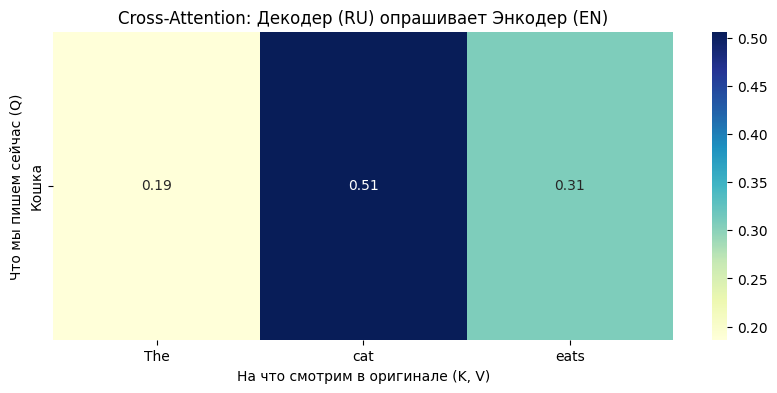

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def softmax(x, axis=-1):
    e_x = np.exp(x - np.max(x, axis=axis, keepdims=True))
    return e_x / np.sum(e_x, axis=axis, keepdims=True)

def cross_attention_demo():
    # Данные 
    english_words = ["The", "cat", "eats"] # Это наш "Контекст" (K и V)
    russian_words = ["Кошка"]               # Это наш "Запрос" (Q)
    
    
    K_encoder = np.array([
        [1.0, 0.0, 0.0, 0.0], # The
        [0.0, 1.0, 0.0, 1.0], # cat (Сущ + Ед.ч)
        [0.0, 0.0, 1.0, 1.0]  # eats (Глагол + Ед.ч)
    ])
    V_encoder = np.array([
        [0.1, 0.0, 0.0], # Смысл слова "The" (почти пустой)
        [0.9, 0.8, 0.1], # Смысл слова "cat" (кошачесть, пушистость)
        [0.2, 0.1, 0.9]  # Смысл слова "eats" (процесс поглощения еды)
    ])

    Q_decoder = np.array([
        [0.0, 1.0, 0.0, 1.0]  # Кошка
    ])
    
    # Математика Cross-Attention (идентична обычной)
    # Сравниваем русский Запрос с английскими Ключами
    scores = Q_decoder @ K_encoder.T / np.sqrt(4)
    weights = softmax(scores, axis=-1)
    
    # 3. Визуализация
    plt.figure(figsize=(10, 4))
    sns.heatmap(weights, annot=True, fmt='.2f',
                xticklabels=english_words, yticklabels=russian_words,
                cmap='YlGnBu', cbar=True) #Yellow-Green-Blue
    
    plt.title('Cross-Attention: Декодер (RU) опрашивает Энкодер (EN)')
    plt.ylabel('Что мы пишем сейчас (Q)')
    plt.xlabel('На что смотрим в оригинале (K, V)')
    plt.show()

cross_attention_demo()